In [1]:
import torch 
torch.cuda.is_available()

True

In [2]:
import sys
sys.path.append('../../utils')
from functions import * 
from importlib import reload
import sys
import umap

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [3]:
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal, AutoGuideList, AutoDelta, AutoMultivariateNormal
from pyro.infer import SVI, Trace_ELBO, RenyiELBO, Predictive
from pyro.distributions import constraints
import matplotlib.pyplot as plt
import math
from importlib import reload
#from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import load_cluster_data

import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


### Settings and Load data

In [4]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 50 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1, # karin had 0.65 
    "pi_prior" : 1 
}

print(hypers["eta"])

cuda
0.02


In [5]:
# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Mammary/'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# still do preprocessing in scipy
import scipy.sparse as sp
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

Reading in data from folder ...
/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Mammary/
Finished reading in data from folder ...
['Vasuclar Smooth Muscle Cell' 'Luminal Progenitor Cells'
 'Artery cells (Endothelial Cells)' 'Vein Cell (Endothelial Cell)'
 'Fibroblasts (Lipofibroblasts)' 'Mature luminal cells' 'Pericytes'
 'T-cells' 'Macrophages' 'B cells' 'NK cells' 'Lymphatic Cells'
 'Mast cell' 'Plasma cells' 'basal cells']
577
53660
                                             cell_id  Cluster  Cluster_Counts  \
0  TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_C9...     1851             236   
1  TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_C9...     1851             236   
2  TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_C9...     1851             236   
3  TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_C9...     1851             236   
4  TSP4_Mammary_NA_SS2_B112795_B134698_Stromal_C9...     1851             236   

           junction_id             gen

In [6]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
577
577


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


In [7]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id
0,0,58122,Luminal Progenitor Cells,27,1.000000,21.0,21,10_100523929_100526398,ENSG00000166136.16
1,0,58679,Luminal Progenitor Cells,29,1.000000,14.0,14,10_100529506_100529766,ENSG00000255339.6
2,0,55040,Luminal Progenitor Cells,625,0.470588,8.0,17,10_130145319_130159994,ENSG00000108010.12
3,0,55040,Luminal Progenitor Cells,627,0.529412,9.0,17,10_130160069_130160795,ENSG00000108010.12
4,0,55042,Luminal Progenitor Cells,628,0.039216,2.0,51,10_130166679_130166918,ENSG00000108010.12


In [8]:
def quick_clust_plot(clust, simple_data):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    print(simple_data_junc.gene_id.unique())
    print(simple_data_junc.junction_id.unique())
    plt.figuresize=(6, 6)
    sns.violinplot(data = simple_data_junc, x = "juncratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title("cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

In [10]:
junction_ids_conversion.Cluster.unique()

array([ 54999,  56947,  56816, ..., 110503, 110508, 110538])

Mature luminal cells                18
Luminal Progenitor Cells            12
Artery cells (Endothelial Cells)     3
Vein Cell (Endothelial Cell)         3
Macrophages                          3
T-cells                              3
Name: cell_type, dtype: int64
['ENSG00000095485.18']
['10_100235764_100236849' '10_100236969_100238021'
 '10_100235764_100238021']


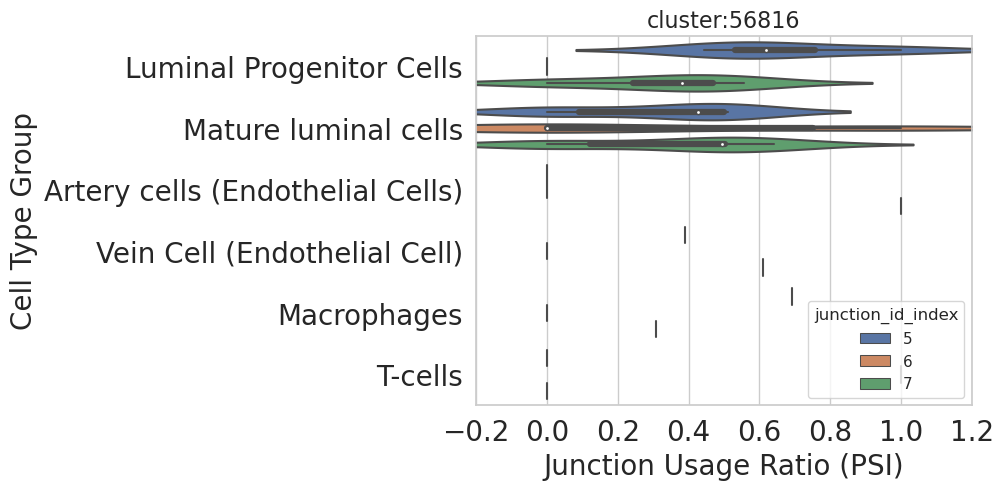

In [11]:
# let's visualize junction usage ratios for a given custer 
clust = 56816
quick_clust_plot(clust, simple_data)

In [12]:
def my_log_prob(y_sparse, total_counts_sparse, pred):
    
    # Extract non-zero elements and their indices from y and total_counts
    y_indices = y_sparse._indices()
    y_values = y_sparse._values()

    total_counts_indices = total_counts_sparse._indices()
    total_counts_values = total_counts_sparse._values()

    # Ensure that y and total_counts align on the same indices
    assert torch.equal(y_indices, total_counts_indices)

    # Compute log probabilities at these indices
    log_probs = dist.Binomial(total_counts_values, pred[y_indices[0], y_indices[1]]).log_prob(y_values)

    # Sum the log probabilities
    return log_probs.sum()

In [15]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

def model(y, total_counts, K):
    N, P = y.shape

    a = pyro.sample("a", dist.Gamma(1., 1.).expand([P]).to_event(1))
    b = pyro.sample("b", dist.Gamma(1., 1.).expand([P]).to_event(1))

    psi_dist = dist.Beta(a, b).expand([K, P]).to_event(2)
    psi = pyro.sample("psi", psi_dist)

    pi = pyro.sample("pi", dist.Dirichlet(torch.ones(K) / K))
    conc = pyro.sample("conc", dist.Gamma(1, 1))

    with pyro.plate('data1', N):
        assign_dist = dist.Dirichlet(pi * conc)
        assign = pyro.sample("assign", assign_dist)

    pred = torch.mm(assign, psi)

    # Use custom log probability
    log_prob = my_log_prob(y, total_counts, pred) # double check that I am not double summing here 
    #pyro.factor("obs", log_prob.sum())
    pyro.factor("obs", log_prob)

In [16]:
def fit(y, total_counts, K, guide, patience=10, min_delta=0.01, lr=0.05, num_epochs=500):
    adam = pyro.optim.Adam({"lr": lr})
    svi = SVI(model, guide, adam, loss=Trace_ELBO())
    pyro.clear_param_store()
    losses = []
    best_loss = float('inf')
    epochs_since_improvement = 0

    for j in range(num_epochs):
        loss = svi.step(y, total_counts, K)
        losses.append(loss)

        # Check for improvement
        if best_loss - loss > min_delta:
            best_loss = loss
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        # Early stopping check
        if epochs_since_improvement >= patience:
            print(f"Stopping early at epoch {j}")
            break

        if j % 10 == 0:
            print(f"Epoch {j}, Loss: {loss}")

        #torch.cuda.empty_cache()  # Attempt to free unused memory
    return losses

In [17]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [18]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [19]:
K = 50 # num factors
J = len(total_counts_tensor[0])
C = len(total_counts_tensor)
print(C, J, K)

guide = AutoDiagonalNormal(model)
print(guide)

577 53661 50
AutoDiagonalNormal()


Epoch 0, Loss: 1813961529.8021288
Epoch 10, Loss: 901231147.827562
Epoch 20, Loss: 426581941.273005
Epoch 30, Loss: 194831596.1008247
Epoch 40, Loss: 102374989.36037326
Epoch 50, Loss: 70222679.76839805
Epoch 60, Loss: 58483816.51036382
Epoch 70, Loss: 53282332.93416643
Epoch 80, Loss: 50505663.242884874
Epoch 90, Loss: 48764095.31958747
Epoch 100, Loss: 47517471.00692344
Epoch 110, Loss: 46546901.506163836
Epoch 120, Loss: 45837162.970107555
Epoch 130, Loss: 45230203.147506
Epoch 140, Loss: 44713377.223783016
Epoch 150, Loss: 44326020.2756598
Epoch 160, Loss: 43891662.18402338
Epoch 170, Loss: 43544961.607803345
Epoch 180, Loss: 43239919.490226984
Epoch 190, Loss: 42961349.291786075


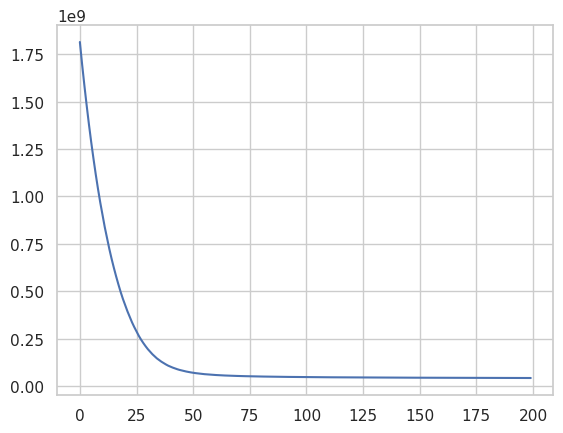

In [20]:
losses = fit(y_tensor, total_counts_tensor, K, guide, lr=0.1, num_epochs=200)
plt.plot(losses, label = "Diagonal variational posterior")

In [21]:
# Sample from the guide (posterior)
guide_trace = pyro.poutine.trace(guide).get_trace(y_tensor, total_counts_tensor, K)

In [22]:
# Extract the latent variables
latent_vars = {name: node["value"].detach().cpu().numpy() for name, node in guide_trace.nodes.items() if node["type"] == "sample"}

In [23]:
latent_vars["pi"]

array([0.02321069, 0.02687171, 0.02481684, 0.02362539, 0.02654339,
       0.02014342, 0.1882446 , 0.09613309, 0.05687217, 0.01771002,
       0.02846826, 0.01558957, 0.03355978, 0.02464165, 0.01312552,
       0.01537803, 0.01179304, 0.01389668, 0.01414166, 0.01547045,
       0.01184675, 0.01221157, 0.01247116, 0.01089643, 0.01458976,
       0.01150843, 0.01053744, 0.01229334, 0.01138842, 0.01579624,
       0.01287056, 0.01185414, 0.009808  , 0.00983639, 0.01053144,
       0.00887513, 0.00907778, 0.00963596, 0.00996649, 0.00903744,
       0.01101064, 0.01151045, 0.00891853, 0.00873157, 0.00709271,
       0.00752444, 0.00729282, 0.00730026, 0.00735073, 0.00799899],
      dtype=float32)

In [24]:
latent_vars["conc"]

array(6.3595834, dtype=float32)

In [25]:
# can we plot assign probabilityies for each cell
assign_post = latent_vars["assign"]
assign_post

array([[7.35402718e-05, 6.36088589e-05, 8.65672890e-04, ...,
        1.07796347e-13, 1.69571284e-11, 3.82554367e-13],
       [1.86522520e-04, 1.43367593e-04, 3.76597280e-04, ...,
        9.07460276e-08, 6.00713257e-09, 4.56174121e-09],
       [2.09614096e-04, 1.01717786e-04, 8.59200663e-04, ...,
        3.09248985e-14, 7.98004978e-12, 5.84932764e-13],
       ...,
       [6.95499602e-06, 2.00899696e-04, 1.32489964e-04, ...,
        2.98704152e-11, 5.70208220e-17, 7.34390982e-14],
       [1.85409142e-03, 4.59489897e-02, 1.48259185e-03, ...,
        1.52533505e-06, 8.87683882e-08, 4.32990106e-08],
       [1.21877747e-04, 1.41221626e-05, 3.27948423e-04, ...,
        7.33557926e-09, 9.93862328e-13, 1.06844922e-10]], dtype=float32)

In [26]:
# Step 1: Run UMAP
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)  # Reducing to 2 dimensions

In [27]:
# Step 2: Prepare cell type labels for coloring
cell_types = cell_ids_conversion['cell_type'].tolist()

T-cells                             175
Luminal Progenitor Cells            113
Fibroblasts (Lipofibroblasts)       105
Mature luminal cells                105
Plasma cells                         14
Macrophages                          13
B cells                              11
Vein Cell (Endothelial Cell)         10
NK cells                              9
Artery cells (Endothelial Cells)      8
basal cells                           6
Pericytes                             2
Vasuclar Smooth Muscle Cell           2
Mast cell                             2
Lymphatic Cells                       2
Name: cell_type, dtype: int64


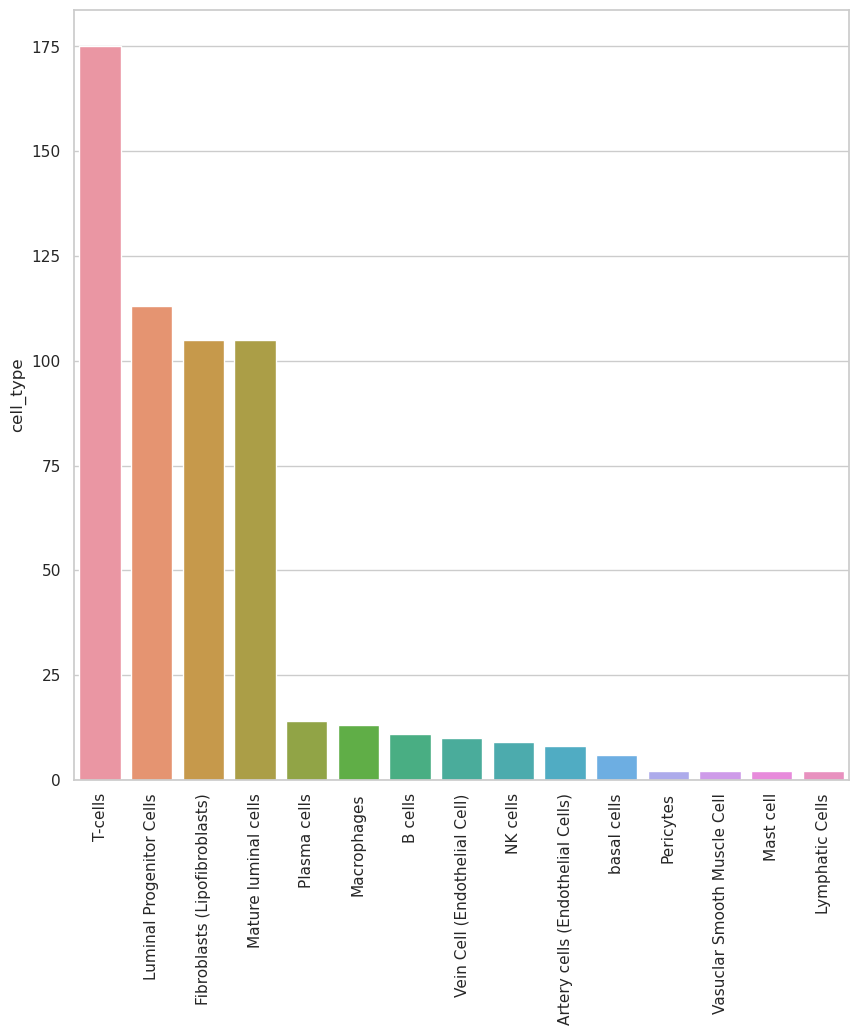

In [28]:
print(cell_ids_conversion.cell_type.value_counts())
# make a barplot of cell type counts
plt.figure(figsize=(10, 10))
sns.barplot(x = cell_ids_conversion.cell_type.value_counts().index, y = cell_ids_conversion.cell_type.value_counts())
plt.xticks(rotation=90)
plt.show()

In [29]:
top_three_cell_types = cell_ids_conversion.cell_type.value_counts()[0:5].index.values
cell_types = cell_ids_conversion['cell_type'].apply(lambda x: x if x in top_three_cell_types else 'Other').tolist()

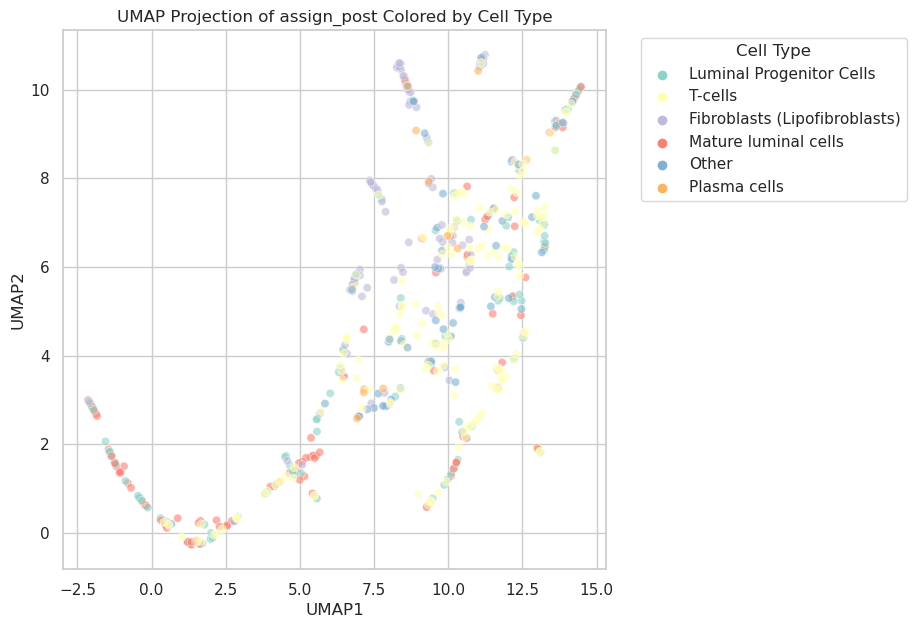

In [30]:
# Plotting
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=cell_types,
    alpha=0.6,
    palette=sns.color_palette("Set3", len(top_three_cell_types) + 1),  # +1 for 'Other' category
    legend='full'
)
plt.title("UMAP Projection of assign_post Colored by Cell Type")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

Text(0.5, 1.0, 'assign_post')

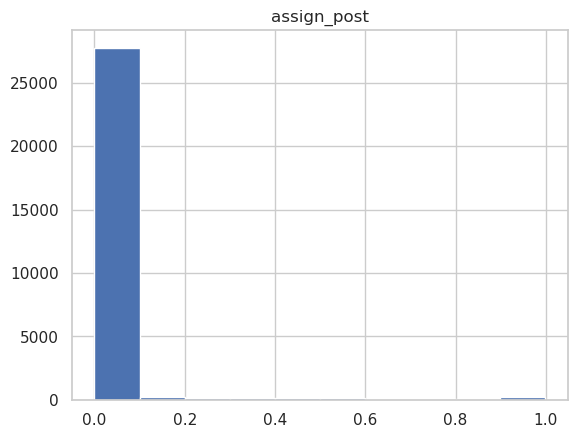

In [31]:
plt.hist(latent_vars["assign"].flatten())
# add title 
plt.title("assign_post")

In [32]:
top_three_cell_types_list = list(top_three_cell_types)
top_three_cell_types_list

['T-cells',
 'Luminal Progenitor Cells',
 'Fibroblasts (Lipofibroblasts)',
 'Mature luminal cells',
 'Plasma cells']

In [33]:
# Create a color palette for the cell types
cell_type_palette = sns.color_palette("hsv", len(top_three_cell_types_list) + 1)

# Map cell types to colors
row_colors = [cell_type_palette[top_three_cell_types_list.index(ct)] if ct in top_three_cell_types_list else cell_type_palette[-1] for ct in cell_types]

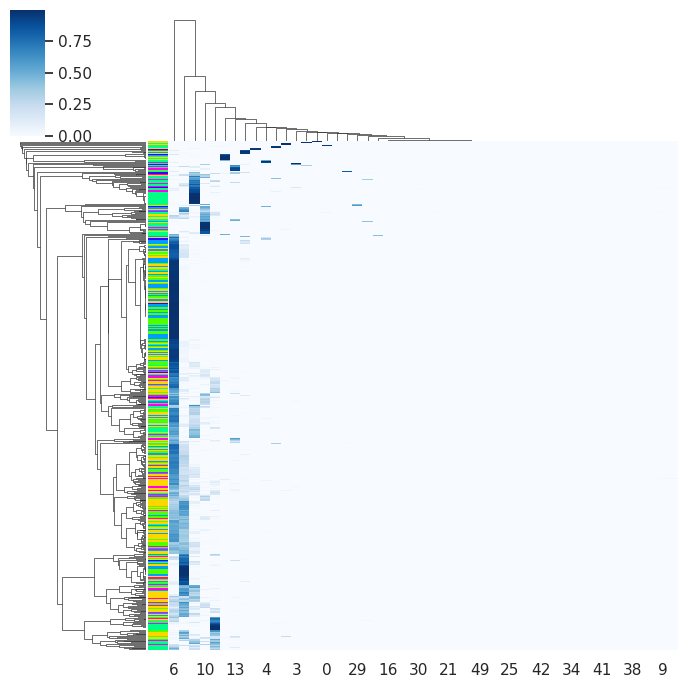

In [34]:
# Generate the clustermap with row colors
sns.clustermap(assign_post, cmap="Blues", figsize=(7, 7),
              row_colors=row_colors,  # Using a list instead of a DataFrame
               yticklabels=False)  # Hide y-axis labels for clarity

plt.show()

In [35]:
# compare to autoencoder (within pyro?) Sophia 
# in autoencoder, currently inputs are 0s for everything that's missing, instead can at least center the non-missing stuff or use median/mean to impute 
# VAE in pyro afterwards... (with a binomial loss on the end) along the lines of this model 
# run original code on simulated data and compare to current code 

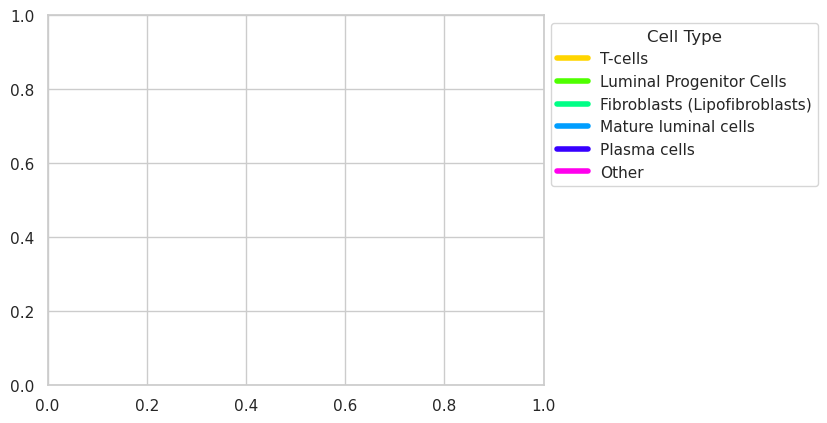

In [36]:
# Create a custom legend for the cell types
# Here, we use the cell_type_palette and top_three_cell_types
legend_handles = [plt.Line2D([0], [0], color=color, lw=4) for color in cell_type_palette]
legend_labels = top_three_cell_types_list + ['Other']

# Add the legend to the plot
plt.legend(handles=legend_handles, labels=legend_labels, title='Cell Type',
           bbox_to_anchor=(1, 1), loc='upper left')